## Fine-tuning CNN for AI-generated Image Detection
In this notebook, we will explore the task of classifying images as real or AI-generated using fine-tuning techniques with several well-known CNN architectures. For this classification task, we will use the CIFAKE dataset, which includes both real and AI-generated images.

Link for the dataset: [CIFAKE: Real and AI-Generated Synthetic Images](https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from IPython.display import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

2026-01-14 15:08:23.659018: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-14 15:08:23.659117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-14 15:08:23.783477: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
dataset_dir = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/" # For Kaggle notebooks. If you run locally, point this line to the CIFAKE directory
print("Loading dataset from: " + dataset_dir)

Loading dataset from: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/


In [3]:
# Check if GPUs are available for training 
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [4]:
img_height = 32
img_width = 32
batch_size = 64

# Load the training data
train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir + "/train",
  seed = 512,
  image_size = (img_height, img_width),
  batch_size = batch_size)

# Load the validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir + "/test",
  seed = 512,
  image_size = (img_height, img_width),
  batch_size = batch_size,
  shuffle=False)

print("Training Classes:")
class_names = train_ds.class_names
print(class_names)

print("Testing Classes:")
class_names = val_ds.class_names
print(class_names)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Training Classes:
['FAKE', 'REAL']
Testing Classes:
['FAKE', 'REAL']


Larger batch sizes are expected to result in significantly longer training times, especially with a substantial training set of 100,000 images. However, the compact size of the images effectively reduces the impact on training duration.

In [5]:
def plot_metrics(history, metric, title):
    # Train metric
    plt.plot(history.history[metric], label=f"Training {metric.capitalize()}")
    # Validation metric
    plt.plot(history.history['val_' + metric], label=f"Validation {metric.capitalize()}")
    plt.xlabel("Epochs")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.legend()
    plt.show()
    
# Constant values that will be shared by all the models
val_true_classes = np.concatenate([y for x, y in val_ds], axis = 0)  # Get true labels
class_names = ['FAKE', 'REAL']
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True) 

### Model Building

All the models share the same architecture for a fair comparison: the input layer, followed by the base model with pre-trained weights from the imagenet, then a few dense layers, and then a unit output with a sigmoid activation function. 

Training is conducted with early stopping criteria monitoring the validation loss, and the best weights will be restored once the training is completed.

In [6]:
# Building the Transfer Learning model using ResNet50
ResNet_base_model = tf.keras.applications.ResNet50(
    include_top = False, 
    weights = 'imagenet', 
    input_shape = (img_height, img_width, 3),
    pooling = 'max'
)
ResNet_base_model.trainable = True

# Create a new model on top of the ResNet50 base
inputs = tf.keras.Input(shape = (img_height, img_width, 3))
x = resnet_preprocess(inputs)
x = ResNet_base_model(x, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256, 
          kernel_regularizer = regularizers.l2(0.01), 
          activity_regularizer = regularizers.l1(0.01), 
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)       
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
ResNet_model = tf.keras.Model(inputs, outputs)

# Compile the model
ResNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Summary of the model
ResNet_model.summary()

94765736/94765736 [==============================] - 0s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 tf.__operators__.getitem (  (None, 32, 32, 3)         0         
 SlicingOpLambda)                                                
                                                                 
 tf.nn.bias_add (TFOpLambda  (None, 32, 32, 3)         0         
 )                                                               
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 batch_normalization (Batch  (None, 2048)              8192      
 Normalization)                                               

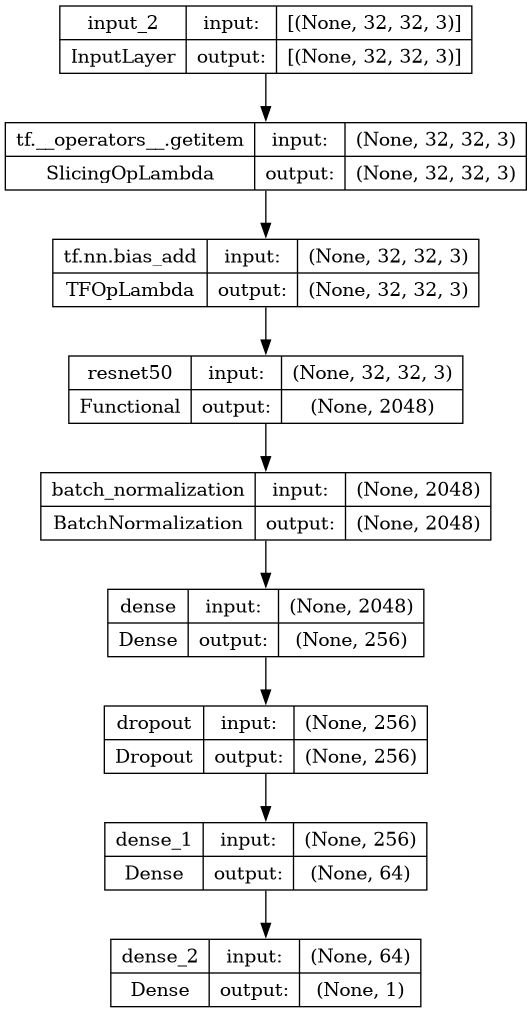

In [7]:
# Visualize the ResNet model architecture
tf.keras.utils.plot_model(ResNet_model, show_shapes = True, to_file = 'ResNet_model.png')
Image('ResNet_model.png')

In [8]:
# Train the Transfer Learning model
print("Starting training with Transfer Learning using ResNet50...")
ResNet_model_history = ResNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)
print("Transfer Learning training finished.")

Starting training with Transfer Learning using ResNet50...
Epoch 1/100


I0000 00:00:1768403473.798959     107 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 [==============================] - 171s 89ms/step - loss: 0.8244 - accuracy: 0.9135 - precision: 0.9179 - recall: 0.9082 - val_loss: 0.2189 - val_accuracy: 0.9360 - val_precision: 0.9495 - val_recall: 0.9211
Epoch 2/100
1563/1563 [==============================] - 75s 48ms/step - loss: 0.2236 - accuracy: 0.9364 - precision: 0.9394 - recall: 0.9329 - val_loss: 0.1914 - val_accuracy: 0.9422 - val_precision: 0.9229 - val_recall: 0.9650
Epoch 3/100
1563/1563 [==============================] - 76s 48ms/step - loss: 0.1915 - accuracy: 0.9459 - precision: 0.9443 - recall: 0.9477 - val_loss: 0.1578 - val_accuracy: 0.9477 - val_precision: 0.9263 - val_recall: 0.9729
Epoch 4/100
1563/1563 [==============================] - 74s 48ms/step - loss: 0.1724 - accuracy: 0.9502 - precision: 0.9442 - recall: 0.9569 - val_loss: 0.1822 - val_accuracy: 0.9505 - val_precision: 0.9540 - val_recall: 0.9466
Epoch 5/100
1563/1563 [==============================] - 75s 48ms/step - loss: 0.1510 - accurac

In [9]:
# Evaluate the model on the test dataset
val_loss, val_accuracy, val_precision, val_recall = ResNet_model.evaluate(val_ds)

# Print the metrics
print(f"Val Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_accuracy:.4f}")
print(f"Val Precision: {val_precision:.4f}")
print(f"Val Recall: {val_recall:.4f}")

313/313 [==============================] - 9s 27ms/step - loss: 0.1342 - accuracy: 0.9582 - precision: 0.9590 - recall: 0.9574
Val Loss: 0.1342
Val Accuracy: 0.9582
Val Precision: 0.9590
Val Recall: 0.9574


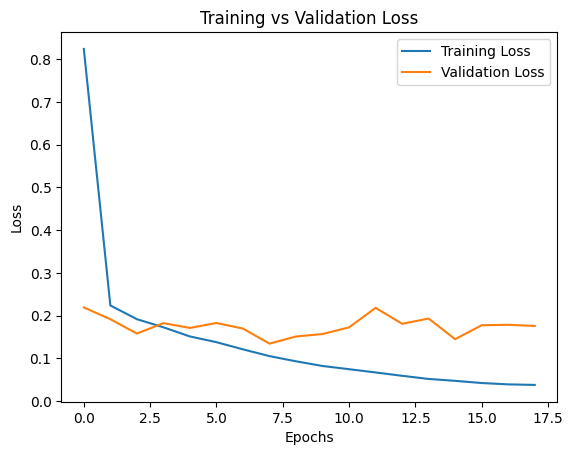

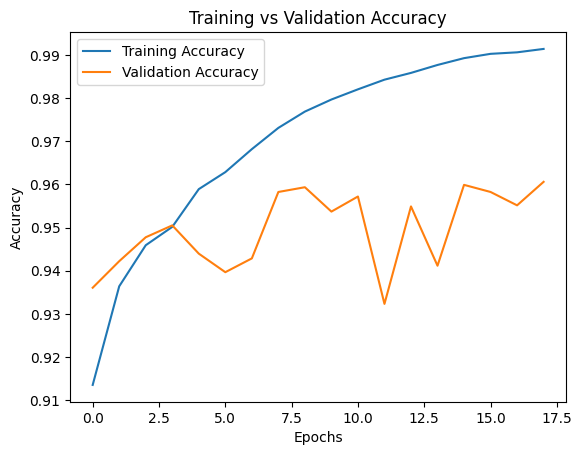

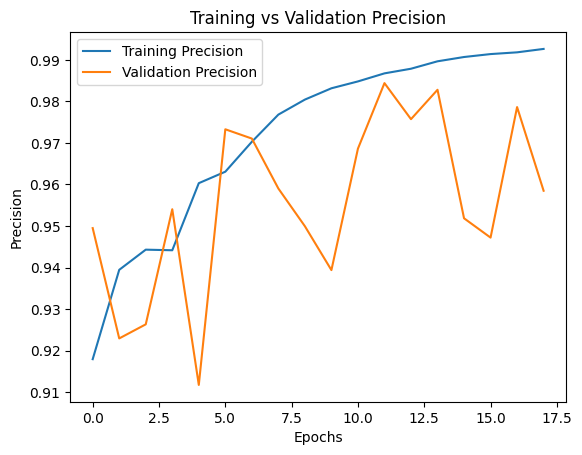

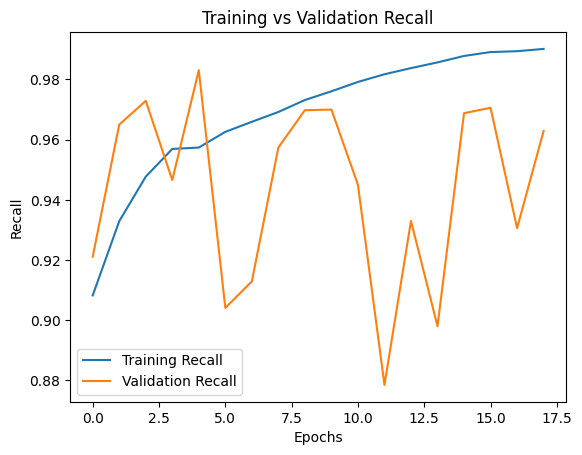

In [10]:
# Plot error rates and metric rates
plot_metrics(ResNet_model_history, 'loss', "Training vs Validation Loss")
plot_metrics(ResNet_model_history, 'accuracy', "Training vs Validation Accuracy")
plot_metrics(ResNet_model_history, 'precision', "Training vs Validation Precision")
plot_metrics(ResNet_model_history, 'recall', "Training vs Validation Recall")

313/313 [==============================] - 8s 23ms/step


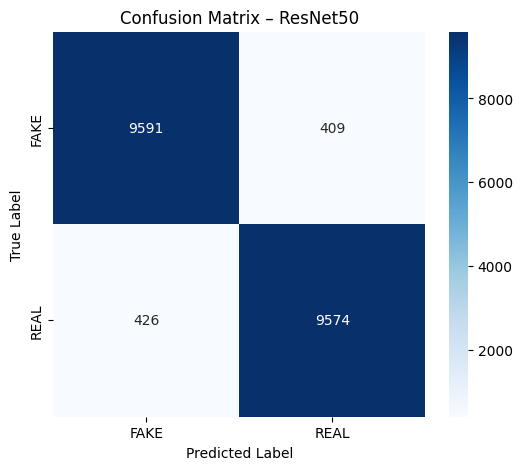

F1 Score: 0.9582
              precision    recall  f1-score   support

        FAKE       0.96      0.96      0.96     10000
        REAL       0.96      0.96      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



In [11]:
# Get model predictions on validation/test dataset
val_pred_probs = ResNet_model.predict(val_ds)

# Convert probabilities to class labels (sigmoid → binary)
val_pred_classes = (val_pred_probs > 0.5).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(val_true_classes, val_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – ResNet50")
plt.show()

f1 = f1_score(val_true_classes, val_pred_classes)
print(f"F1 Score: {f1:.4f}")

print(classification_report(
    val_true_classes,
    val_pred_classes,
    target_names=class_names
))

The model with EfficientNet as the base is the clear winner with an accuracy of 97.29%; however, MobileNet is also a great option since its model size is significantly lower than EfficientNet's, with a minor decrease in performance.